# **CS715 - Project:  Structured Sparsification of Gated Recurrent Neural Networks**

## **Notebook-1: Base LSTM**

## **STEP 1: Reading the Kaggle Emotion Dataset**



In [2]:
import torch
import pandas as pd


train_df = pd.read_csv("/content/train.txt", sep=';', header=None, names=['text', 'emotion'])
val_df   = pd.read_csv("/content/val.txt", sep=';', header=None, names=['text', 'emotion'])
test_df  = pd.read_csv("/content/test.txt", sep=';', header=None, names=['text', 'emotion'])


print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (16000, 2)
Val shape: (2000, 2)
Test shape: (2000, 2)


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## **STEP 2: Inspecting the data**

In [3]:
print(train_df.columns)
train_df.head(10)

Index(['text', 'emotion'], dtype='object')


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [4]:
train_df['emotion'].value_counts()

,count
emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


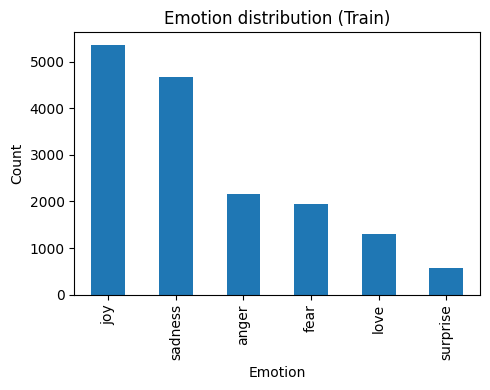

In [5]:
import matplotlib.pyplot as plt

emotion_counts = train_df['emotion'].value_counts()
plt.figure(figsize=(5, 4))
emotion_counts.plot(kind='bar')
plt.title("Emotion distribution (Train)")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [6]:
train_df.sample(10)

,text,emotion
6970,i feel like i have been learning through the j...,joy
15120,i have come to a place in my life where i feel...,love
9721,i alive i feel so defeated with this issue,sadness
10836,i was feeling really shitty invaded disrespect...,sadness
14517,im not feeling so well right now so ill write ...,joy
6823,i also havent been feeling photo friendly of l...,joy
12616,i got that straight i realized that i was deal...,fear
3872,i just wanted to write this post because i m s...,sadness
9562,i hope all knitters will rise above their hurt...,love
8916,i have played a great set i feel really hesita...,fear


## **STEP 3: Label Encoding**

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Fit on all emotions at once to ensure consistent mapping
all_emotions = pd.concat([train_df['emotion'], val_df['emotion'], test_df['emotion']])
label_encoder.fit(all_emotions)

train_df['label'] = label_encoder.transform(train_df['emotion'])
val_df['label']   = label_encoder.transform(val_df['emotion'])
test_df['label']  = label_encoder.transform(test_df['emotion'])

print(label_encoder.classes_)
train_df.head()


['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


,text,emotion,label
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0


In [8]:
train_df['label'].value_counts()

,count
label,
2,5362
4,4666
0,2159
1,1937
3,1304
5,572


In [9]:
X_train = train_df['text'].tolist()
y_train = train_df['label'].tolist()

X_val = val_df['text'].tolist()
y_val = val_df['label'].tolist()

X_test = test_df['text'].tolist()
y_test = test_df['label'].tolist()


## **Step 4: Tokenization => Building Vocabulary => Convert text to fixed length sizes**

In [10]:
import re
from collections import Counter

def tokenize(text):
    # lower-case
    text = text.lower()
    # keep letters, numbers, apostrophes; replace others with space
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    # split on whitespace
    return text.split()

In [11]:
tokenize("I've been feeling a little burdened lately, wasn't I?")

["i've", 'been', 'feeling', 'a', 'little', 'burdened', 'lately', "wasn't", 'i']

In [12]:

MAX_VOCAB_SIZE = 20000
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

counter = Counter()
for sent in X_train:
    counter.update(tokenize(sent))

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for i, (word, _) in enumerate(most_common, start=2):
    vocab[word] = i

print("Vocab size:", len(vocab))

Vocab size: 15214


In [13]:
import numpy as np

MAX_LEN = 50  # max tokens per sentence

def encode_sentence(text, vocab, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]

    # pad or truncate
    if len(ids) < max_len:
        ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return np.array(ids, dtype=np.int64)


In [14]:
X_train_ids = np.stack([encode_sentence(t, vocab) for t in X_train])
X_val_ids   = np.stack([encode_sentence(t, vocab) for t in X_val])
X_test_ids  = np.stack([encode_sentence(t, vocab) for t in X_test])

y_train_arr = np.array(y_train, dtype=np.int64)
y_val_arr   = np.array(y_val, dtype=np.int64)
y_test_arr  = np.array(y_test, dtype=np.int64)

print("Train IDs shape:", X_train_ids.shape)
print("Val IDs shape:", X_val_ids.shape)
print("Test IDs shape:", X_test_ids.shape)


Train IDs shape: (16000, 50)
Val IDs shape: (2000, 50)
Test IDs shape: (2000, 50)


## **STEP 5: Create Dataset and DataLoader**

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

class EmotionDataset(Dataset):
    def __init__(self, X_ids, y_labels):
        self.X = torch.tensor(X_ids, dtype=torch.long)
        self.y = torch.tensor(y_labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [16]:
train_dataset = EmotionDataset(X_train_ids, y_train_arr)
val_dataset   = EmotionDataset(X_val_ids, y_val_arr)
test_dataset  = EmotionDataset(X_test_ids, y_test_arr)

In [17]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [18]:
batch_X, batch_y = next(iter(train_loader))

print("Batch X shape:", batch_X.shape)
print("Batch y shape:", batch_y.shape)
print(batch_X[0])  # first encoded sentence
print(batch_y[0])  # corresponding label


Batch X shape: torch.Size([64, 50])
Batch y shape: torch.Size([64])
tensor([    2,   213,     5,     3,   588,    29,    49,     2,    21,    48,
        10256,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])
tensor(4)


# **STEP 6:  Baseline LSTM**

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [20]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_arr)  # labels 0–5
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_arr
)

print("Classes:", classes)
print("Class weights:", class_weights)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Weights tensor:", class_weights_tensor)

Classes: [0 1 2 3 4 5]
Class weights: [1.23513973 1.37669936 0.49732687 2.04498978 0.57151022 4.66200466]
Weights tensor: tensor([1.2351, 1.3767, 0.4973, 2.0450, 0.5715, 4.6620], device='cuda:0')


In [21]:
class EmotionLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (h_n, c_n) = self.lstm(embedded)
        last_hidden = h_n[-1]
        out = self.dropout(last_hidden)
        logits = self.fc(out)
        return logits

In [22]:
vocab_size = len(vocab)
embed_dim = 100
hidden_dim = 128
num_classes = len(label_encoder.classes_)
pad_idx = vocab[PAD_TOKEN]

model = EmotionLSTM(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx).to(device)
print(model)

EmotionLSTM(
  (embedding): Embedding(15214, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [24]:
def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [25]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_batches = 0

    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(logits, batch_y)
        total_loss += loss.item()
        total_acc += acc
        total_batches += 1

    return total_loss / total_batches, total_acc / total_batches


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_batches = 0

    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        acc = compute_accuracy(logits, batch_y)

        total_loss += loss.item()
        total_acc += acc
        total_batches += 1

    return total_loss / total_batches, total_acc / total_batches

In [26]:
EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch:02d}: "
          f"Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")

Epoch 01: Train Loss = 1.5910, Train Acc = 0.3239, Val Loss = 1.5821, Val Acc = 0.3525
Epoch 02: Train Loss = 1.5771, Train Acc = 0.3325, Val Loss = 1.5831, Val Acc = 0.3511
Epoch 03: Train Loss = 1.5723, Train Acc = 0.3373, Val Loss = 1.5862, Val Acc = 0.3506
Epoch 04: Train Loss = 1.5680, Train Acc = 0.3406, Val Loss = 1.5865, Val Acc = 0.3491
Epoch 05: Train Loss = 1.5595, Train Acc = 0.3399, Val Loss = 1.5978, Val Acc = 0.3428
Epoch 06: Train Loss = 1.4406, Train Acc = 0.3576, Val Loss = 1.3186, Val Acc = 0.4106
Epoch 07: Train Loss = 1.1686, Train Acc = 0.4205, Val Loss = 1.1881, Val Acc = 0.4346
Epoch 08: Train Loss = 1.0132, Train Acc = 0.4747, Val Loss = 1.1165, Val Acc = 0.4526
Epoch 09: Train Loss = 0.8715, Train Acc = 0.5761, Val Loss = 0.9674, Val Acc = 0.5757
Epoch 10: Train Loss = 0.6312, Train Acc = 0.7546, Val Loss = 0.7051, Val Acc = 0.7793
Epoch 11: Train Loss = 0.3671, Train Acc = 0.8867, Val Loss = 0.5543, Val Acc = 0.8418
Epoch 12: Train Loss = 0.2770, Train Acc = 

In [27]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss = {test_loss:.4f}, Test Acc = {test_acc:.4f}")

Test Loss = 0.4779, Test Acc = 0.8628


In [28]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_X)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

       anger       0.91      0.85      0.88       275
        fear       0.89      0.87      0.88       224
         joy       0.84      0.89      0.87       695
        love       0.56      0.72      0.63       159
     sadness       0.97      0.90      0.93       581
    surprise       0.84      0.55      0.66        66

    accuracy                           0.86      2000
   macro avg       0.83      0.80      0.81      2000
weighted avg       0.87      0.86      0.86      2000



<Figure size 800x600 with 0 Axes>

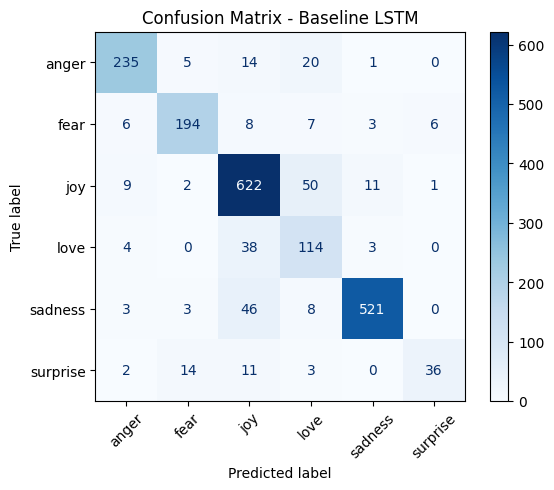

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure model is in evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_X)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Emotion label names (use your LabelEncoder classes)
label_names = label_encoder.classes_

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Baseline LSTM")
plt.xticks(rotation=45)
plt.show()

In [30]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print("Total trainable parameters:", total_params)


Total trainable parameters: 1639934


In [31]:
torch.save(model.state_dict(), "emotion_lstm_baseline.pt")